In [5]:
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from pgmpy.estimators import HillClimbSearch

redoing preprocessing

In [2]:
rows = []

with open("../data/raw/yelp_academic_dataset_business.json", "r", encoding="utf-8") as file:
    for line in file:
        business = json.loads(line)

        # iclude "restaurant" businesses only 
        categories = business.get("categories")
        if categories is None or "Restaurants" not in categories:
            continue

        attrs = business.get("attributes", {})
        if attrs is None:
            attrs = {}

        rows.append({
            # continuous features
            "stars": business.get("stars"),
            "review_count": business.get("review_count"),

            # categorical features
            "price_range": attrs.get("RestaurantsPriceRange2", "Unknown"),
            #"noise_level": attrs.get("NoiseLevel", "Unknown"),
            #"wifi": attrs.get("WiFi", "Unknown"),
            
            # boolean features
            "BusinessAcceptsCreditCards": attrs.get("BusinessAcceptsCreditCards"),
            "delivery": attrs.get("RestaurantsDelivery", "Unknown"),
            "takeout": attrs.get("RestaurantsTakeOut", "Unknown"),
            "reservations": attrs.get("RestaurantsReservations", "Unknown"),
            "outdoor_seating": attrs.get("OutdoorSeating", "Unknown"),
            #"good_for_groups": attrs.get("RestaurantsGoodForGroups", "Unknown")     
        })

df = pd.DataFrame(rows)
print(df.shape)
print(df.head())
print("\n")

# remove sparse cols: noise_level, wifi, and good_for_groups 
for col in df.columns:
    missing_ratio = (df[col] == "Unknown").mean()
    print(f"ratio of missing {col}: {round(missing_ratio, 4)}")

# convert stars to classification target: predict high if stars >= 3.7, else low
df["rating"] = np.where(df["stars"] >= 3.7, "high", "low")
df.drop(columns=["stars"], inplace=True)

# discretize review count
df["review_count"] = pd.qcut(
    df["review_count"],
    q=3,
    labels=["few", "moderate", "many"]
)

# convert rows and cols to strings
for col in df.columns:
    df[col] = df[col].astype(str)
    df[col] = (df[col].str.replace("u'", "", regex=False).str.replace("'", "", regex=False).str.strip())
print("\n")

# create train/test split stratified by rating col
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df["rating"])
print("Train:", train_df.shape)
print("Test:", test_df.shape)

(52268, 8)
   stars  review_count price_range BusinessAcceptsCreditCards delivery  \
0    4.0            80           1                      False    False   
1    2.0             6           1                       True     True   
2    3.0            19           1                       True    False   
3    1.5            10           1                       True     True   
4    4.0            10     Unknown                        NaN  Unknown   

   takeout reservations outdoor_seating  
0     True      Unknown           False  
1     True        False            True  
2     True        False            True  
3     True        False            True  
4  Unknown        False            None  


ratio of missing stars: 0.0
ratio of missing review_count: 0.0
ratio of missing price_range: 0.1486
ratio of missing BusinessAcceptsCreditCards: 0.0
ratio of missing delivery: 0.0883
ratio of missing takeout: 0.068
ratio of missing reservations: 0.1753
ratio of missing outdoor_seating: 0.1

boostraping multiple runs to determine stability

In [12]:
graphs = []
edge_cnt = {}
runs = 50

for i in range(runs):
    subset = train_df.sample(frac=0.8, replace=True, random_state=i)

    hc = HillClimbSearch(subset)
    best_structure = hc.estimate(scoring_method='bic-d')
    graphs.append(best_structure)

    for edge in best_structure.edges():
        edge_cnt[edge] = edge_cnt.get(edge, 0) + 1

/tmp/ipykernel_60439/3705298086.py:8: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(subset)
  0%|          | 16/1000000 [00:00<9:00:53, 30.81it/s]
/tmp/ipykernel_60439/3705298086.py:8: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(subset)
  0%|          | 17/1000000 [00:00<8:16:23, 33.58it/s]
/tmp/ipykernel_60439/3705298086.py:8: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(subset)
  0%|          | 17/1000000 [00:00<8:35:59, 32.30it/s]
/tmp/ipykernel_60439/3705298086.py:8: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  

graph analysis

In [8]:
#building reference graph
hc = HillClimbSearch(train_df)
reference = hc.estimate(scoring_method='bic-d')
print("Learned edges:")
print(list(reference.edges()))

/tmp/ipykernel_60439/154339983.py:2: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(train_df)
  0%|          | 16/1000000 [00:00<10:28:48, 26.50it/s]

Learned edges:
[('review_count', 'outdoor_seating'), ('review_count', 'rating'), ('price_range', 'review_count'), ('price_range', 'rating'), ('BusinessAcceptsCreditCards', 'price_range'), ('BusinessAcceptsCreditCards', 'reservations'), ('BusinessAcceptsCreditCards', 'outdoor_seating'), ('BusinessAcceptsCreditCards', 'delivery'), ('BusinessAcceptsCreditCards', 'takeout'), ('BusinessAcceptsCreditCards', 'review_count'), ('BusinessAcceptsCreditCards', 'rating'), ('delivery', 'reservations'), ('delivery', 'review_count'), ('takeout', 'delivery'), ('reservations', 'price_range'), ('reservations', 'outdoor_seating')]


<Axes: xlabel='frequency', ylabel='edge'>

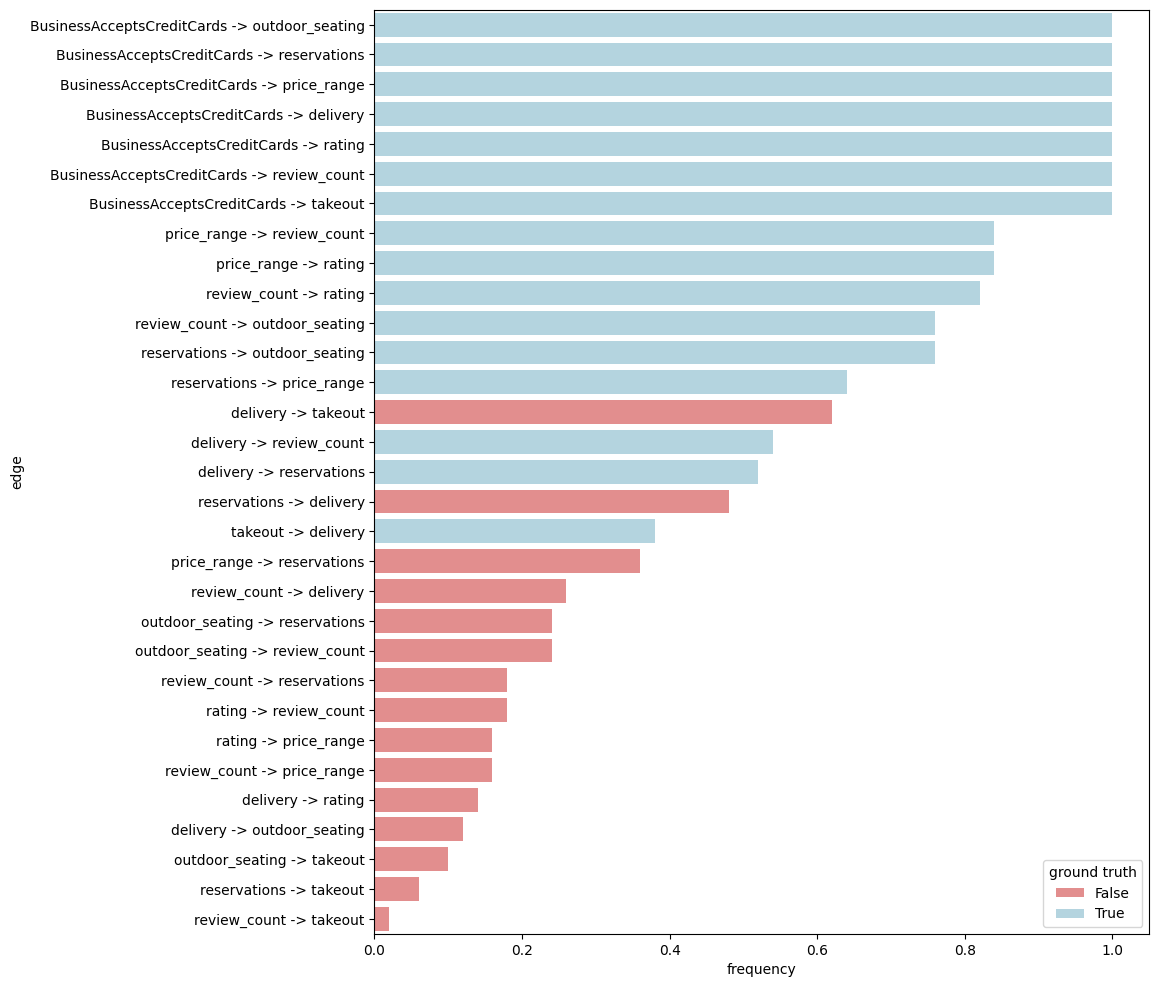

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
edge_freq = []
for edge, count in edge_cnt.items():
    u, v = edge
    edge_freq.append({
        "edge": f"{u} -> {v}",
        "frequency": (count / runs),
        "ground truth": edge in reference.edges()
        })

#format as df
df_edges = pd.DataFrame(edge_freq)
df_edges.sort_values(by="frequency", ascending=False, inplace=True)

plt.figure(figsize=(10, 12))
sns.barplot(
    data = df_edges,
    x = "frequency",
    y = "edge",
    hue = "ground truth",
    dodge = False,
    palette={True: 'lightblue', False: 'lightcoral'}
)